In [1]:
!git clone --branch 4-pareto-test https://github.com/GoharKhachatryan/GenAI_project.git
%cd GenAI_project
from google.colab import drive
drive.mount('/content/drive')

Cloning into 'GenAI_project'...
remote: Enumerating objects: 290, done.
remote: Counting objects: 100% (290/290), done.
remote: Compressing objects: 100% (248/248), done.
remote: Total 290 (delta 175), reused 110 (delta 39), pack-reused 0 (from 0)
Receiving objects: 100% (290/290), 1.70 MiB | 6.92 MiB/s, done.
Resolving deltas: 100% (175/175), done.
/content/GenAI_project
Mounted at /content/drive


## Condition evaluation

This notebook performs the following operations:

1. Generates samples from the held-out condition sets (the test set).

2. Extracts features from the genetated samples.

3. Analyzes the distribution of the $||c - \hat{c}||$.

4. Performs a feature-level analysis.

## Import

In [2]:
import random
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from prepare_dataset import PairedCIFAR10
from pseudo_crossmodal import (
    extract_condition,
    load_pca,
)

from scripts.unet import UNet
from scripts.blocks import (
    ResBlock,
    ScaleShiftResBlock,
)
from scripts.model import (
    ConditionalDenoiser,
    ConditionalDenoiserConcat,
)
from scripts.diffusion import DDPM
from scripts.samplers import (
    ddpm_sample_respaced,
    ddim_sample,
)

## Reproducibility & Configs

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


In [ ]:
NUM_STEPS = 100
BATCH_SIZE = 128

DDIM_ETA = 0.0

In [6]:
CHECKPOINTS_PATH = "/path/to/the/checkpoints/"
# Download my pre-trained weights using the URL in the README file
CHECKPOINTS = {
    "add_add": CHECKPOINTS_PATH + "add_add/" + "best_model.pt",
    "concat_add": CHECKPOINTS_PATH + "concat_add/" + "best_model.pt",
    "add_scale_shift": CHECKPOINTS_PATH + "add_scale_shift/" + "best_model.pt",
    "concat_scale_shift": CHECKPOINTS_PATH + "concat_scale_shift/" + "best_model.pt",
}

# Since the colab runtime can be interrupted, save the results after each update here
# Download my version using the URL in the README file
RESULTS_PATH = "/content/drive/MyDrive/for_bostongene/cycle_results_full_test.pt"

## Test set

In [ ]:
test_dataset = PairedCIFAR10("test")

print("Test set size:", len(test_dataset))

image, cond, label = test_dataset[0]

print("Image shape:", image.shape)
print("Condition shape:", cond.shape)
print("Label:", label)

Test set size: 10000
Image shape: torch.Size([3, 32, 32])
Condition shape: torch.Size([16])
Label: tensor(3)


In [ ]:
eval_indices = list(range(len(test_dataset)))
NUM_EVAL_SAMPLES = len(eval_indices)

print("Number of evaluation samples:", len(eval_indices))

Number of evaluation samples: 10000


In [ ]:
generator = torch.Generator().manual_seed(SEED)

perm = torch.randperm(
    len(eval_indices),
    generator=generator,
).tolist()

eval_indices = [
    eval_indices[i]
    for i in perm
]

## Preprocessing

In [ ]:
eval_images = []
eval_conditions = []
eval_labels = []

for idx in eval_indices:
    image, cond, label = test_dataset[idx]

    eval_images.append(image)
    eval_conditions.append(cond)
    eval_labels.append(label)

eval_images = torch.stack(eval_images)
eval_conditions = torch.stack(eval_conditions)
eval_labels = torch.tensor(eval_labels)

print(eval_images.shape)
print(eval_conditions.shape)
print(eval_labels.shape)

torch.Size([10000, 3, 32, 32])
torch.Size([10000, 16])
torch.Size([10000])


In [ ]:
reference_checkpoint = torch.load(
    CHECKPOINTS["add_add"],
    map_location="cpu",
)

cond_mean = reference_checkpoint["cond_mean"]
cond_std = reference_checkpoint["cond_std"]

print(cond_mean.shape)
print(cond_std.shape)

torch.Size([16])
torch.Size([16])


In [ ]:
eval_conditions_norm = (
    eval_conditions - cond_mean
) / (cond_std + 1e-8)

In [ ]:
pca_state = load_pca()

In [ ]:
generator = torch.Generator().manual_seed(SEED)

# Creats a fixed initial noise for each sample for fair evaluation
x_init_all = torch.randn(
    len(eval_indices),
    3,
    32,
    32,
    generator=generator,
)

## Model

In [ ]:
# Re-use this function instead of manually creating the architecture for each experiment (4)
def build_model(variant):
    if variant == "add_add":
        unet = UNet(
            in_channels=3,
            out_channels=3,
            base_channels=64,
            emb_dim=256,
            block_cls=ResBlock,
        )

        model = ConditionalDenoiser(
            unet=unet,
            time_dim=256,
            cond_dim=16,
            emb_dim=256,
        )

    elif variant == "concat_add":
        unet = UNet(
            in_channels=3,
            out_channels=3,
            base_channels=64,
            emb_dim=256,
            block_cls=ResBlock,
        )

        model = ConditionalDenoiserConcat(
            unet=unet,
            time_dim=256,
            cond_dim=16,
            emb_dim=256,
        )

    elif variant == "add_scale_shift":
        unet = UNet(
            in_channels=3,
            out_channels=3,
            base_channels=64,
            emb_dim=256,
            block_cls=ScaleShiftResBlock,
        )

        model = ConditionalDenoiser(
            unet=unet,
            time_dim=256,
            cond_dim=16,
            emb_dim=256,
        )

    elif variant == "concat_scale_shift":
        unet = UNet(
            in_channels=3,
            out_channels=3,
            base_channels=64,
            emb_dim=256,
            block_cls=ScaleShiftResBlock,
        )

        model = ConditionalDenoiserConcat(
            unet=unet,
            time_dim=256,
            cond_dim=16,
            emb_dim=256,
        )

    else:
        raise ValueError(
            f"Unknown model variant: {variant}"
        )

    return model

In [ ]:
def load_model(variant, device):
    model = build_model(variant)

    checkpoint = torch.load(
        CHECKPOINTS[variant],
        map_location=device,
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model = model.to(device)
    model.eval()

    return model

In [ ]:
diffusion = DDPM(
    timesteps=1000,
    schedule="cosine",
    device=device,
)

## Cycle metrics

In [ ]:
def compute_cycle_metrics(
    cond_true,
    cond_hat,
    cond_std,
):
    error = cond_true - cond_hat

    raw_l2 = torch.linalg.vector_norm(
        error,
        dim=1,
    )

    standardized_error = (
        error
        / (cond_std + 1e-8)
    )

    standardized_l2 = torch.linalg.vector_norm(
        standardized_error,
        dim=1,
    )

    feature_mae = (
        error.abs().mean(dim=0)
    )

    feature_mae_std = (
        standardized_error.abs().mean(dim=0)
    )

    return {
        "raw_l2": raw_l2,
        "standardized_l2": standardized_l2,
        "feature_mae": feature_mae,
        "feature_mae_std": feature_mae_std,
    }

## Evaluation

In [ ]:
@torch.no_grad()
def evaluate_cycle_consistency(
    model,
    sampler_name,
    cond_original,
    cond_normalized,
    x_init_all,
    cond_std,
    pca_state,
    diffusion,
    batch_size=128,
    num_steps=100,
    eta=0.0,
):
    all_cond_hat = []

    start_time = time.time()

    for start in range(
        0,
        len(cond_original),
        batch_size,
    ):
        end = min(
            start + batch_size,
            len(cond_original),
        )

        cond_batch = (
            cond_normalized[start:end]
            .to(device)
        )

        x_init_batch = (
            x_init_all[start:end]
            .to(device)
        )

        if sampler_name == "ddim":
            generated = ddim_sample(
                model=model,
                ddpm=diffusion,
                cond=cond_batch,
                num_steps=num_steps,
                eta=eta,
                x_init=x_init_batch,
            )

        elif sampler_name == "ddpm":
            # Resetting globally for every batch is NOT what we want.
            # Seed once before the evaluation loop instead.
            generated = ddpm_sample_respaced(
                model=model,
                ddpm=diffusion,
                cond=cond_batch,
                num_steps=num_steps,
                x_init=x_init_batch,
            )

        else:
            raise ValueError(
                f"Unknown sampler: {sampler_name}"
            )

        cond_hat = extract_condition(
            generated,
            pca_state,
        )

        all_cond_hat.append(
            cond_hat.cpu()
        )

    cond_hat = torch.cat(
        all_cond_hat,
        dim=0,
    )

    metrics = compute_cycle_metrics(
        cond_true=cond_original,
        cond_hat=cond_hat,
        cond_std=cond_std,
    )

    metrics["cond_hat"] = cond_hat
    metrics["runtime_sec"] = time.time() - start_time

    return metrics

## Experiment config

In [ ]:
def save_results(results, path=RESULTS_PATH):
    torch.save(results, path)

In [7]:
import os

if os.path.exists(RESULTS_PATH):
    results = torch.load(
        RESULTS_PATH,
        map_location="cpu",
    )
    print(f"Loaded {len(results)} existing results.")
else:
    results = {}

Loaded 8 existing results.


In [ ]:
def build_summary(results):
    rows = []

    for (variant, sampler), result in results.items():
        rows.append({
            "variant": variant,
            "sampler": sampler,
            "mean_raw_l2": result["raw_l2"].mean().item(),
            "std_raw_l2": result["raw_l2"].std().item(),
            "mean_standardized_l2":
                result["standardized_l2"].mean().item(),
            "std_standardized_l2":
                result["standardized_l2"].std().item(),
            "runtime_sec": result["runtime_sec"],
        })

    return pd.DataFrame(rows)

## A loop version

In [10]:
MODEL_VARIANTS = [
    "add_add",
    "concat_add",
    "add_scale_shift",
    "concat_scale_shift",
]

SAMPLERS = [
    "ddpm",
    "ddim",
]

In [ ]:
for variant in MODEL_VARIANTS:
    print(f"\nLoading {variant}")

    model = load_model(variant, device)

    for sampler_name in SAMPLERS:

        key = (variant, sampler_name)

        # Skip already-computed configurations
        if key in results:
            print(f"  Skipping {key}: already computed.")
            continue

        print(
            f"  Evaluating {sampler_name}..."
        )

        # Reset RNG once before this complete evaluation
        torch.manual_seed(SEED)

        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED)

        result = evaluate_cycle_consistency(
            model=model,
            sampler_name=sampler_name,
            cond_original=eval_conditions,
            cond_normalized=eval_conditions_norm,
            x_init_all=x_init_all,
            cond_std=cond_std,
            pca_state=pca_state,
            diffusion=diffusion,
            batch_size=BATCH_SIZE,
            num_steps=NUM_STEPS,
            eta=DDIM_ETA,
        )

        results[key] = result

        # Save immediately after successful completion
        save_results(results)

        print(
            "    standardized L2:",
            result["standardized_l2"]
            .mean()
            .item()
        )

        print(
            "    runtime:",
            round(
                result["runtime_sec"],
                1,
            ),
            "sec",
        )

        print("    Results saved.")

    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


Loading add_add
  Evaluating ddpm...
    standardized L2: 0.3508899211883545
    runtime: 439.4 sec
    Results saved.
  Evaluating ddim...
    standardized L2: 0.5585135817527771
    runtime: 443.1 sec
    Results saved.

Loading concat_add
  Evaluating ddpm...
    standardized L2: 0.35873958468437195
    runtime: 443.8 sec
    Results saved.
  Evaluating ddim...
    standardized L2: 0.4629572331905365
    runtime: 443.0 sec
    Results saved.

Loading add_scale_shift
  Evaluating ddpm...
    standardized L2: 0.2457181215286255
    runtime: 451.4 sec
    Results saved.
  Evaluating ddim...
    standardized L2: 0.4007309079170227
    runtime: 451.3 sec
    Results saved.

Loading concat_scale_shift
  Evaluating ddpm...
    standardized L2: 0.30169641971588135
    runtime: 452.9 sec
    Results saved.
  Evaluating ddim...
    standardized L2: 0.4143257737159729
    runtime: 452.8 sec
    Results saved.


## Build a summary from csv

In [ ]:
if os.path.exists(RESULTS_PATH):
    results = torch.load(
        RESULTS_PATH,
        map_location="cpu",
    )
    print(f"Loaded {len(results)} existing results.")

Loaded 8 existing results.


In [ ]:
summary = build_summary(results)

summary.to_csv(
    "/path/to/save/cycle_summary_full_test.csv",
    index=False,
)

## Plotting & Analysis

In [8]:
# A distribution plot of standardized L2 error
plot_rows = []

for (variant, sampler), result in results.items():
    values = result["standardized_l2"].numpy()

    for value in values:
        plot_rows.append({
            "variant": variant,
            "sampler": sampler,
            "standardized_l2": value,
        })

plot_df = pd.DataFrame(plot_rows)

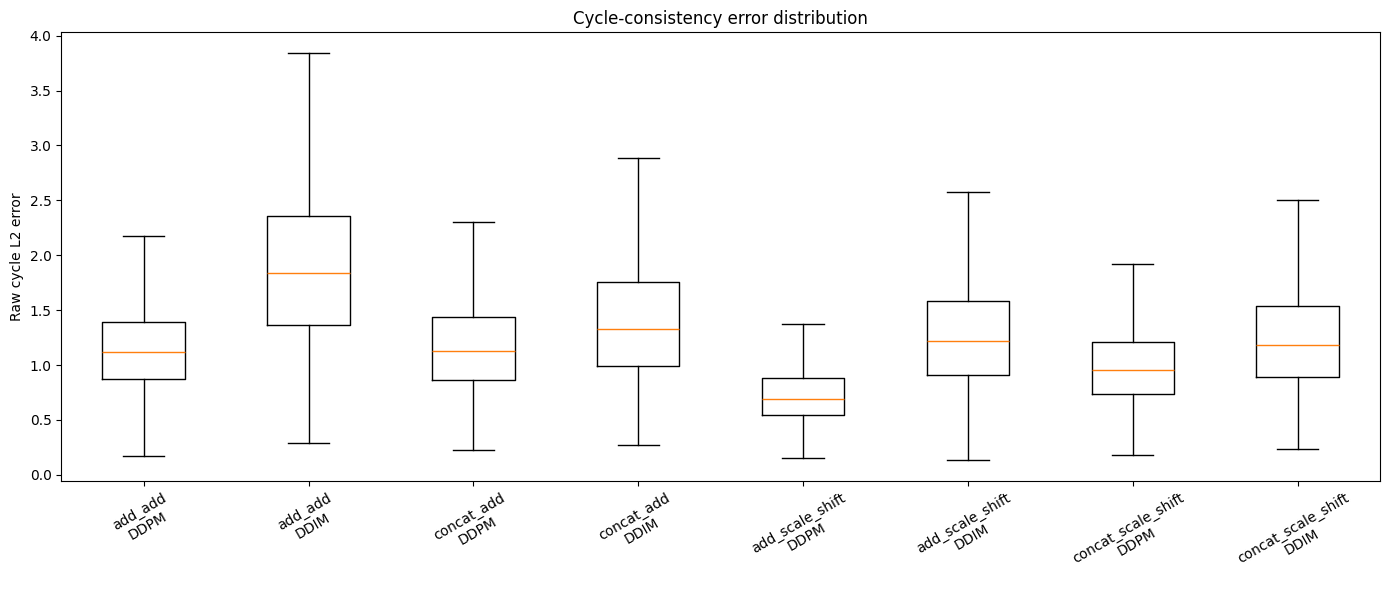

In [12]:
labels = []
data = []

for variant in MODEL_VARIANTS:
    for sampler in SAMPLERS:
        key = (variant, sampler)

        data.append(
            results[key]["raw_l2"].numpy()
        )

        labels.append(
            f"{variant}\n{sampler.upper()}"
        )

plt.figure(figsize=(14, 6))

plt.boxplot(
    data,
    tick_labels=labels,
    showfliers=False,
)

plt.ylabel("Raw cycle L2 error")
plt.title(
    "Cycle-consistency error distribution"
)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

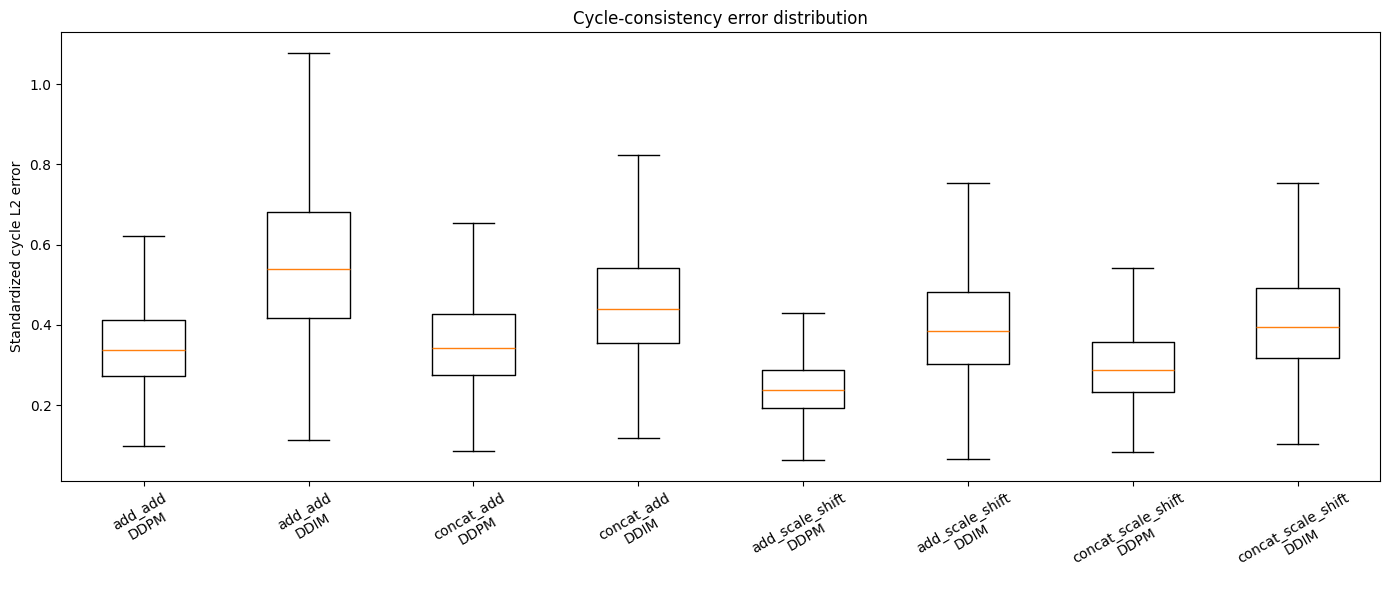

In [11]:
labels = []
data = []

for variant in MODEL_VARIANTS:
    for sampler in SAMPLERS:
        key = (variant, sampler)

        data.append(
            results[key]["standardized_l2"].numpy()
        )

        labels.append(
            f"{variant}\n{sampler.upper()}"
        )

plt.figure(figsize=(14, 6))

plt.boxplot(
    data,
    tick_labels=labels,
    showfliers=False,
)

plt.ylabel("Standardized cycle L2 error")
plt.title(
    "Cycle-consistency error distribution"
)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Cycle-consistency distribution.


At 100 inference steps, DDPM produces lower standardized cycle-consistency error than DDIM for all four conditioning architectures. The scale-and-shift ResBlock variants show lower error distributions than the additive ResBlock variants. Among the tested models, additive fusion with scale-and-shift modulation gives the lowest median and the most compact error distribution. This suggests that stronger modulation of intermediate feature maps improves preservation of the conditioning signal during generation.

In [14]:
feature_names = [
    "row_q1", "row_q2", "row_q3", "row_q4",
    "col_q1", "col_q2", "col_q3", "col_q4",
    "mean_R", "mean_G", "mean_B",
    "luma_std",
    "PCA_1", "PCA_2", "PCA_3", "PCA_4",
]

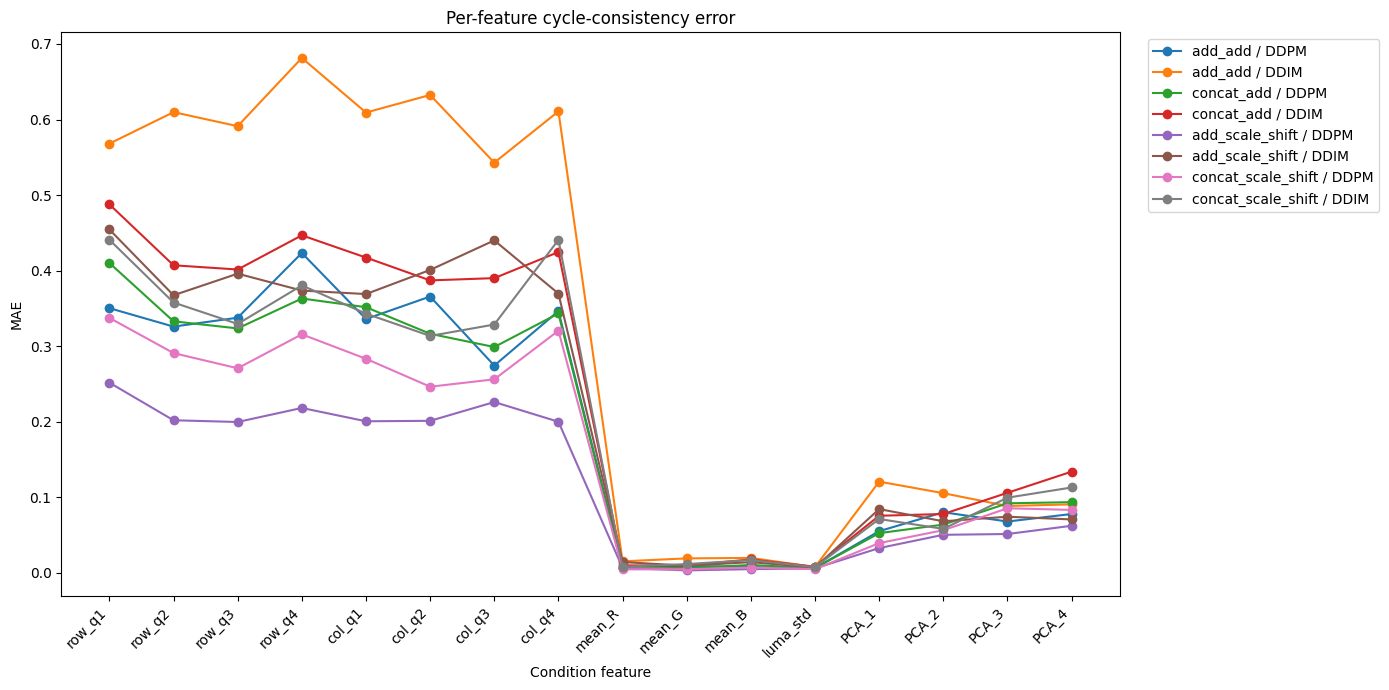

In [15]:
plt.figure(figsize=(14, 7))

x = np.arange(len(feature_names))

for (variant, sampler), result in results.items():
    values = (
        result["feature_mae"]
        .numpy()
    )

    plt.plot(
        x,
        values,
        marker="o",
        label=f"{variant} / {sampler.upper()}",
    )

plt.xticks(
    x,
    feature_names,
    rotation=45,
    ha="right",
)

plt.ylabel("MAE")
plt.xlabel("Condition feature")

plt.title(
    "Per-feature cycle-consistency error"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

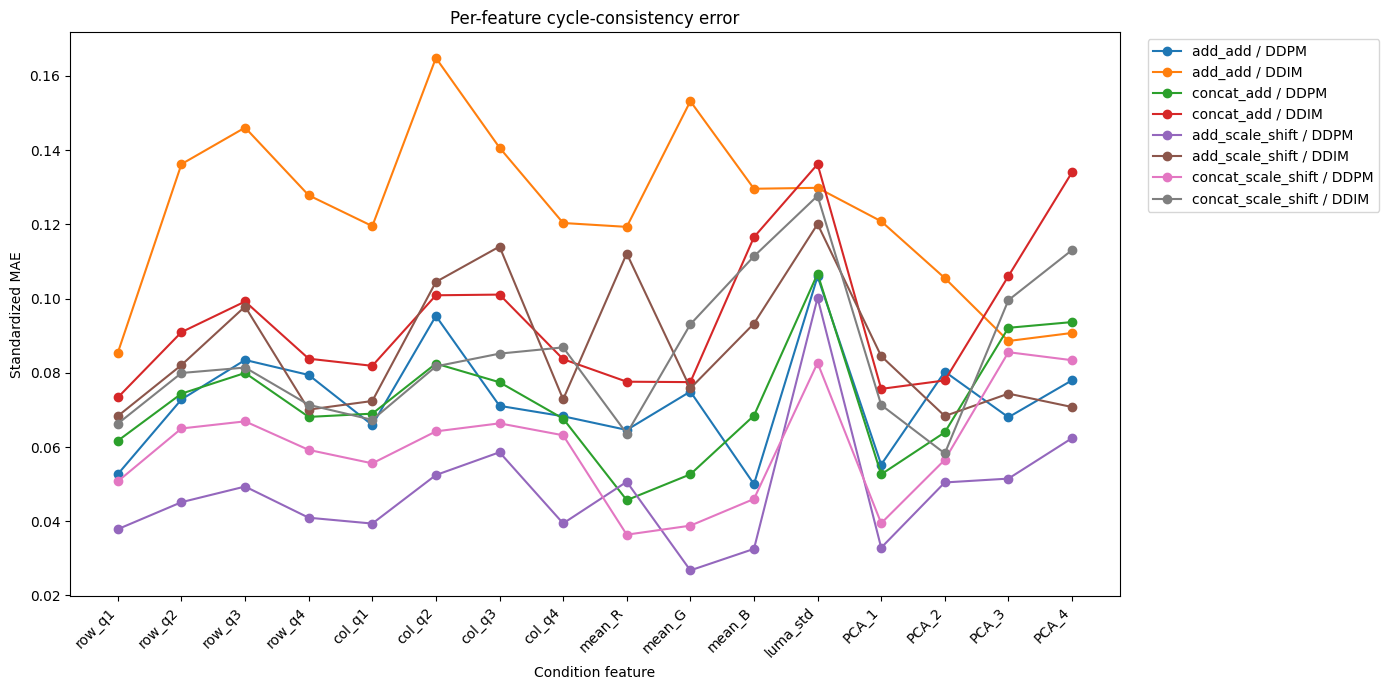

In [ ]:
plt.figure(figsize=(14, 7))

x = np.arange(len(feature_names))

for (variant, sampler), result in results.items():
    values = (
        result["feature_mae_std"]
        .numpy()
    )

    plt.plot(
        x,
        values,
        marker="o",
        label=f"{variant} / {sampler.upper()}",
    )

plt.xticks(
    x,
    feature_names,
    rotation=45,
    ha="right",
)

plt.ylabel("Standardized MAE")
plt.xlabel("Condition feature")

plt.title(
    "Per-feature cycle-consistency error"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

Per-feature analysis.


The cycle-consistency error is not distributed uniformly across the 16 conditioning dimensions. Some features, particularly luminance standard deviation and several PCA/color-related components, are harder to preserve than others. The scale-and-shift models reduce error across many features simultaneously, which suggests that their advantage is not caused by a single feature dominating the global L2 metric. DDPM also shows lower feature-wise errors than DDIM for most configurations at the fixed 100-step budget.

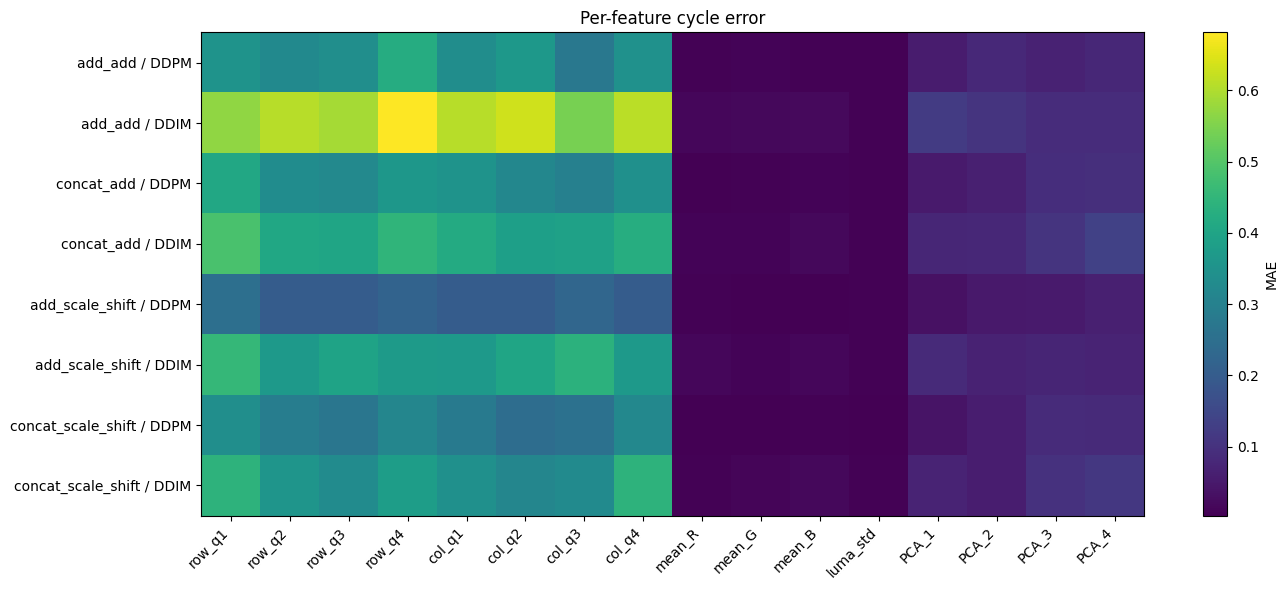

In [16]:
matrix = []
row_labels = []

for variant in MODEL_VARIANTS:
    for sampler in SAMPLERS:
        matrix.append(
            results[
                (variant, sampler)
            ]["feature_mae"].numpy()
        )

        row_labels.append(
            f"{variant} / {sampler.upper()}"
        )

matrix = np.stack(matrix)

plt.figure(figsize=(14, 6))

plt.imshow(
    matrix,
    aspect="auto",
)

plt.colorbar(
    label="MAE"
)

plt.yticks(
    np.arange(len(row_labels)),
    row_labels,
)

plt.xticks(
    np.arange(len(feature_names)),
    feature_names,
    rotation=45,
    ha="right",
)

plt.title(
    "Per-feature cycle error"
)

plt.tight_layout()
plt.show()

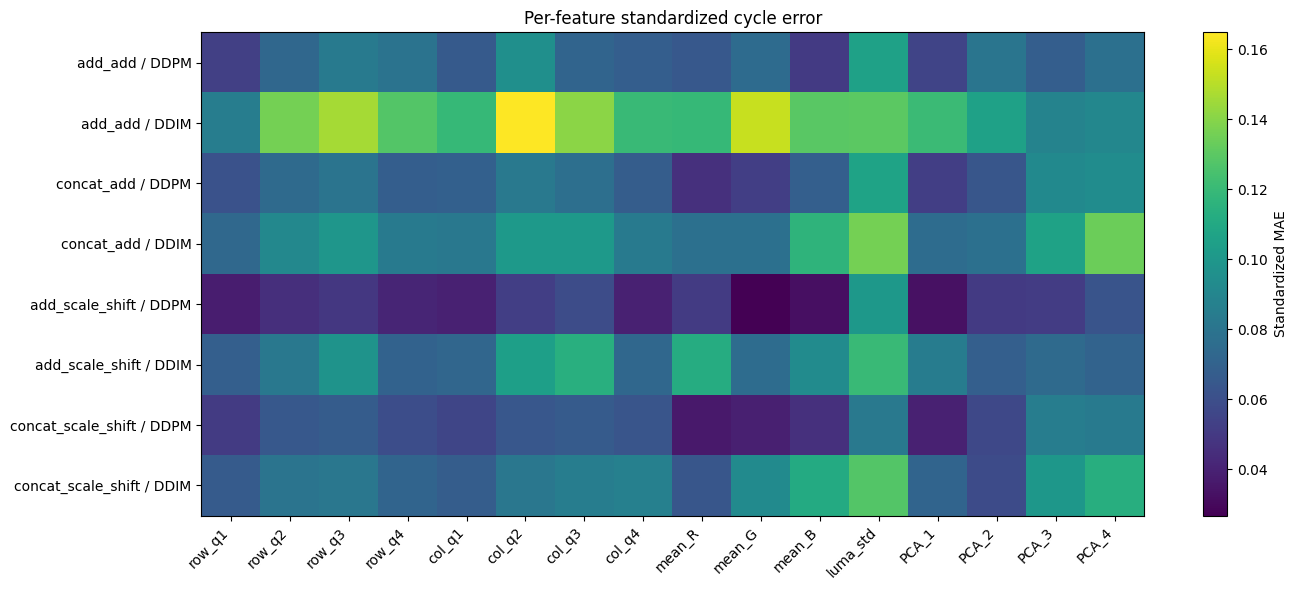

In [17]:
matrix = []
row_labels = []

for variant in MODEL_VARIANTS:
    for sampler in SAMPLERS:
        matrix.append(
            results[
                (variant, sampler)
            ]["feature_mae_std"].numpy()
        )

        row_labels.append(
            f"{variant} / {sampler.upper()}"
        )

matrix = np.stack(matrix)

plt.figure(figsize=(14, 6))

plt.imshow(
    matrix,
    aspect="auto",
)

plt.colorbar(
    label="Standardized MAE"
)

plt.yticks(
    np.arange(len(row_labels)),
    row_labels,
)

plt.xticks(
    np.arange(len(feature_names)),
    feature_names,
    rotation=45,
    ha="right",
)

plt.title(
    "Per-feature standardized cycle error"
)

plt.tight_layout()
plt.show()

## Feature correlation & Preservation

In [ ]:
train_dataset = PairedCIFAR10("train")

train_conditions = torch.stack([
    train_dataset[i][1]
    for i in range(len(train_dataset))
])

train_cond_np = train_conditions.numpy()

train_corr = np.corrcoef(
    train_cond_np,
    rowvar=False,
)

print(train_corr.shape)

(16, 16)


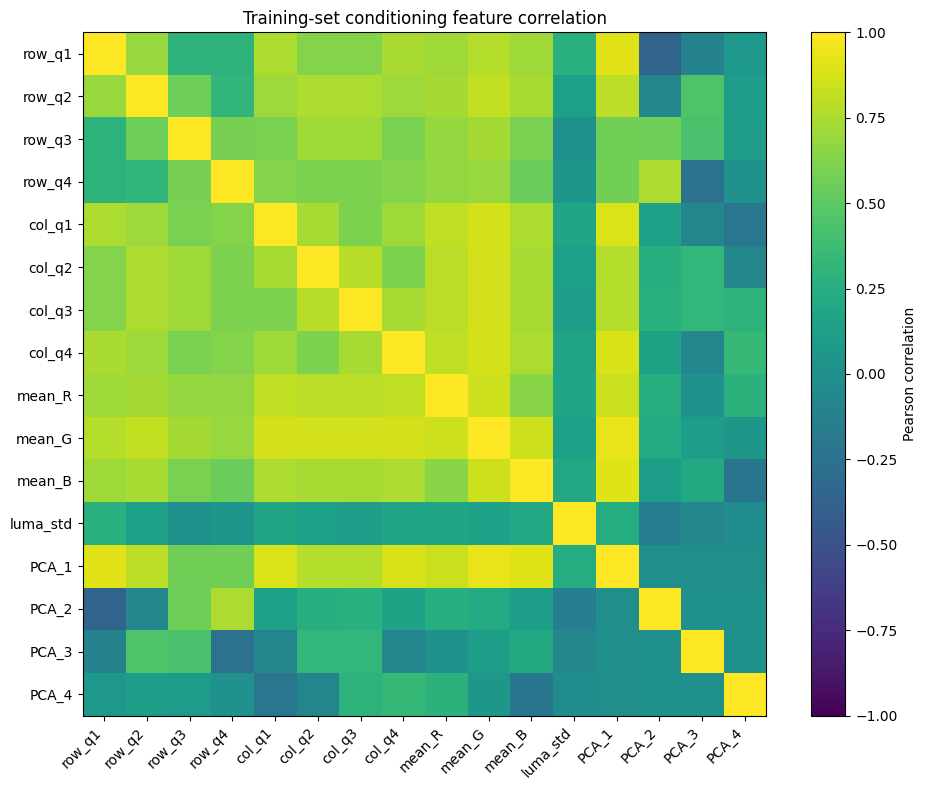

In [ ]:
plt.figure(figsize=(10, 8))

plt.imshow(
    train_corr,
    vmin=-1,
    vmax=1,
)

plt.colorbar(label="Pearson correlation")

plt.xticks(
    np.arange(len(feature_names)),
    feature_names,
    rotation=45,
    ha="right",
)

plt.yticks(
    np.arange(len(feature_names)),
    feature_names,
)

plt.title(
    "Training-set conditioning feature correlation"
)

plt.tight_layout()
plt.show()

In [ ]:
abs_corr = np.abs(
    train_corr.copy()
)

np.fill_diagonal(
    abs_corr,
    np.nan,
)

feature_redundancy = np.nanmean(
    abs_corr,
    axis=1,
)

In [ ]:
redundancy_df = pd.DataFrame({
    "feature": feature_names,
    "redundancy": feature_redundancy,
})

redundancy_df

,feature,redundancy
0,row_q1,0.529481
1,row_q2,0.556095
2,row_q3,0.516219
3,row_q4,0.480491
4,col_q1,0.578829
5,col_q2,0.586485
6,col_q3,0.601433
7,col_q4,0.586674
8,mean_R,0.605152
9,mean_G,0.644081


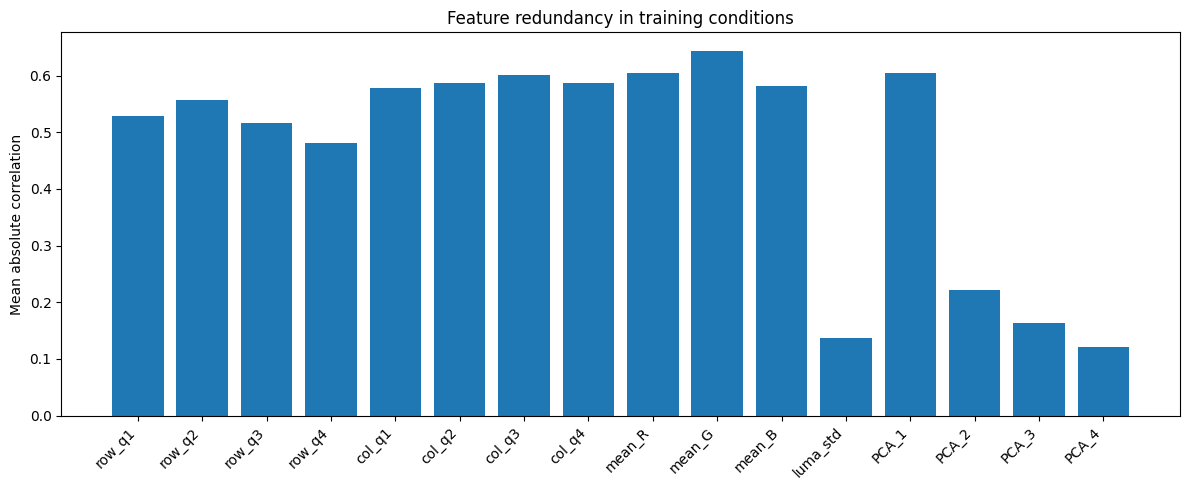

In [ ]:
plt.figure(figsize=(12, 5))

plt.bar(
    feature_names,
    feature_redundancy,
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.ylabel(
    "Mean absolute correlation"
)

plt.title(
    "Feature redundancy in training conditions"
)

plt.tight_layout()
plt.show()

In [ ]:
mean_feature_error_all = np.mean(
    [
        result["feature_mae_std"].numpy()
        for result in results.values()
    ],
    axis=0,
)

mean_feature_error_ddpm = np.mean(
    [
        result["feature_mae_std"].numpy()
        for (variant, sampler), result
        in results.items()
        if sampler == "ddpm"
    ],
    axis=0,
)

mean_feature_error_ddim = np.mean(
    [
        result["feature_mae_std"].numpy()
        for (variant, sampler), result
        in results.items()
        if sampler == "ddim"
    ],
    axis=0,
)

In [ ]:
correlation_analysis_df = pd.DataFrame({
    "feature": feature_names,
    "redundancy": feature_redundancy,
    "mean_error_all": mean_feature_error_all,
    "mean_error_ddpm": mean_feature_error_ddpm,
    "mean_error_ddim": mean_feature_error_ddim,
})

correlation_analysis_df

,feature,redundancy,mean_error_all,mean_error_ddpm,mean_error_ddim
0,row_q1,0.529481,0.062058,0.050752,0.073363
1,row_q2,0.556095,0.080819,0.064333,0.097305
2,row_q3,0.516219,0.088025,0.069917,0.106134
3,row_q4,0.480491,0.075095,0.061924,0.088267
4,col_q1,0.578829,0.071371,0.057468,0.085274
5,col_q2,0.586485,0.093297,0.073613,0.112982
6,col_q3,0.601433,0.089300,0.068375,0.110224
7,col_q4,0.586674,0.075280,0.059629,0.090930
8,mean_R,0.605152,0.071244,0.049323,0.093164
9,mean_G,0.644081,0.074085,0.048288,0.099883


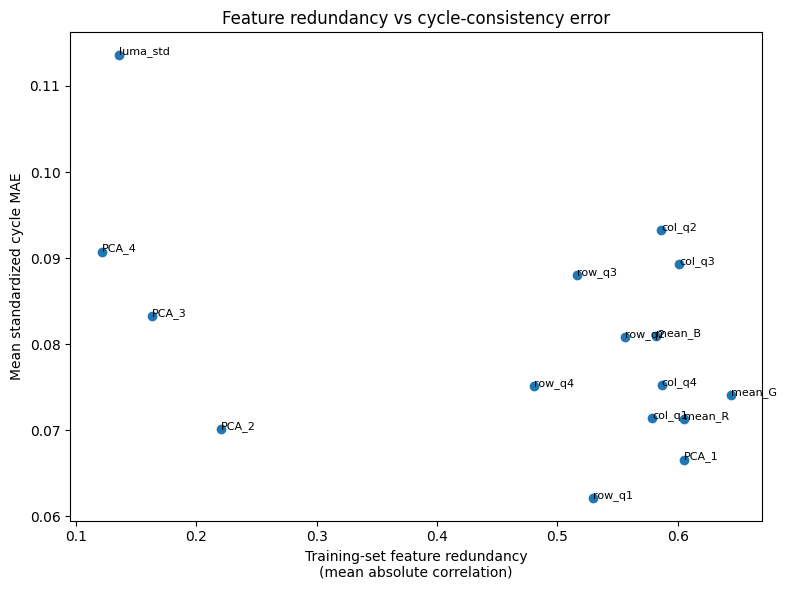

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    feature_redundancy,
    mean_feature_error_all,
)

for i, name in enumerate(feature_names):
    plt.annotate(
        name,
        (
            feature_redundancy[i],
            mean_feature_error_all[i],
        ),
        fontsize=8,
    )

plt.xlabel(
    "Training-set feature redundancy\n"
    "(mean absolute correlation)"
)

plt.ylabel(
    "Mean standardized cycle MAE"
)

plt.title(
    "Feature redundancy vs cycle-consistency error"
)

plt.tight_layout()
plt.show()

In [ ]:
rho_all, p_all = spearmanr(
    feature_redundancy,
    mean_feature_error_all,
)

print(
    "All configurations:"
)

print(
    "Spearman rho:",
    rho_all,
)

print(
    "p-value:",
    p_all,
)

All configurations:
Spearman rho: -0.3588235294117647
p-value: 0.17230386289263244


In [ ]:
rho_ddpm, p_ddpm = spearmanr(
    feature_redundancy,
    mean_feature_error_ddpm,
)

rho_ddim, p_ddim = spearmanr(
    feature_redundancy,
    mean_feature_error_ddim,
)

print(
    "DDPM:",
    rho_ddpm,
    p_ddpm,
)

print(
    "DDIM:",
    rho_ddim,
    p_ddim,
)

DDPM: -0.7264705882352941 0.0014361826350785247
DDIM: -0.008823529411764706 0.9741279946623942


To investigate why some conditioning dimensions are preserved better than others, I compared each feature's cycle-consistency error with its redundancy in the training data.

Redundancy was defined as the mean absolute Pearson correlation of a feature with the other 15 conditioning dimensions.

The overall relationship between redundancy and preservation is negative but only moderate: Spearman $\rho=-0.359$ with $p=0.172$. Therefore, feature correlation alone does not fully explain preservation quality across all model/sampler configurations.

However, the relationship differs strongly by sampler. For DDPM, the correlation is substantial and statistically clear $\rho=-0.726$, $p=0.0014$: features that are more strongly correlated with other conditioning dimensions tend to have lower standardized reconstruction error. This is consistent with the idea that redundant features can be supported by multiple related cues during generation.

For DDIM, this pattern disappears $\rho\approx-0.009$, $p=0.974$. Thus, feature redundancy does not appear to explain the DDIM per-feature error pattern at the fixed 100-step setting. This suggests that sampler dynamics also affect which conditioning information is preserved.

In [ ]:
# for luma_std only
redundancy_rank = pd.Series(
    feature_redundancy
).rank(
    ascending=False
)

error_rank = pd.Series(
    mean_feature_error_all
).rank(
    ascending=False
)

rank_df = pd.DataFrame({
    "feature": feature_names,
    "redundancy": feature_redundancy,
    "redundancy_rank": redundancy_rank,
    "error": mean_feature_error_all,
    "error_rank": error_rank,
})

rank_df

,feature,redundancy,redundancy_rank,error,error_rank
0,row_q1,0.529481,10.0,0.062058,16.0
1,row_q2,0.556095,9.0,0.080819,8.0
2,row_q3,0.516219,11.0,0.088025,5.0
3,row_q4,0.480491,12.0,0.075095,10.0
4,col_q1,0.578829,8.0,0.071371,12.0
5,col_q2,0.586485,6.0,0.093297,2.0
6,col_q3,0.601433,4.0,0.089300,4.0
7,col_q4,0.586674,5.0,0.075280,9.0
8,mean_R,0.605152,3.0,0.071244,13.0
9,mean_G,0.644081,1.0,0.074085,11.0


In [ ]:
rank_df[
    rank_df["feature"] == "luma_std"
]

,feature,redundancy,redundancy_rank,error,error_rank
11,luma_std,0.136136,15.0,0.113659,1.0


**luma_std** is a particularly clear example. It is the second least redundant feature in the training representation (mean absolute correlation $\approx$ 0.136) and has the highest average standardized cycle-consistency error ($\approx$ 0.114).

This supports the interpretation that luminance variation contains relatively independent information that is more difficult for the model to preserve than highly redundant brightness/color statistics.

A similar, though not perfect, pattern appears among the PCA features. **PCA_1** has high redundancy ($\approx$ 0.605) and relatively low error ($\approx$ 0.067), while **PCA_3** and **PCA_4** have much lower redundancy and larger errors. **PCA_2** is an exception, showing that redundancy is not the only factor: feature semantics, model representation capacity, and the reverse-sampling dynamics also influence preservation.

Overall, the results suggest that scale-and-shift conditioning improves preservation across many dimensions, while DDPM benefits more strongly from redundant conditioning structure. The feature-level analysis also shows that no single factor fully determines preservation quality, motivating the step-count and sampler trade-off analysis in Task 4.